In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)

In [2]:
# Load data
df = pd.read_csv('DS-DATA.csv', low_memory=False)
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,3,4,3,3,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,2,3,5,2,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,4,4,5,4,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,2,3,4,2,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,3,3,5,3,3,4,4,5,4,3,3,3,3,Satisfied


In [3]:
# Shape, types
print('Shape:', df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape: (129880, 24)

Column names:
['ID', 'Gender', 'Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Departure and Arrival Time Convenience', 'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling', 'Satisfaction']

Data types:
ID                                          int64
Gender                                     object
Age                                         int64
Customer Type                              object
Type of Travel                             object
Class                                      object
Flight Distance                            object
Departure Delay                             int64
Arrival Delay                             float64
Departure and Arrival Time Convenience      int64
Ease o

In [4]:
# Basic Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  object 
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  object 
 4   Type of Travel                          129880 non-null  object 
 5   Class                                   129880 non-null  object 
 6   Flight Distance                         129880 non-null  object 
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129880 non-null  int64  
 10  Ease of Online Booking                  1298

In [5]:
# Drop ID column
df = df.drop(columns=['ID'])
print("Dropped 'id' column - not a predictor, just a row identifier")
print("New Shape:", df.shape)

Dropped 'id' column - not a predictor, just a row identifier
New Shape: (129880, 23)


In [6]:
# Missing value analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("=== Missing Values ===")
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal missing: {df.isnull().sum().sum()}")

=== Missing Values ===
               Missing Count  Missing %
Arrival Delay            393        0.3

Total missing: 393


In [7]:
# Fix missing values
print("Missing before:", df['Arrival Delay'].isnull().sum())

df['Arrival Delay'] = df['Arrival Delay'].fillna(df['Arrival Delay'].median())

print("Missing after:", df['Arrival Delay'].isnull().sum())
print("Median used:", df['Arrival Delay'].median())

Missing before: 393
Missing after: 0
Median used: 0.0


In [8]:
# Check for the mixed-type column
print("Flight Distance dtype:", df['Flight Distance'].dtype)
print("\nSample value:")
print(df['Flight Distance'].head(20).tolist())

# Check if any non-numeric values exist
non_numeric = pd.to_numeric(df['Flight Distance'], errors='coerce').isnull().sum()
print(f"\nNon-numeric entries in Flight Distance: {non_numeric}")

Flight Distance dtype: object

Sample value:
['821', '821', '853', '1905', '3470', '3788', '1963', '853', '2607', '2822', '821', '421', '453', '853', '853', '821', '821', '821', '853', '821']

Non-numeric entries in Flight Distance: 3


In [9]:
# Fix Flight Distance mixed type
df['Flight Distance'] = pd.to_numeric(df['Flight Distance'], errors='coerce')

print("Dtype after fix:", df['Flight Distance'].dtype)
print("New nulls created:", df['Flight Distance'].isnull().sum())

# Fill the 3 new nulls with median
df['Flight Distance'] = df["Flight Distance"].fillna(df["Flight Distance"].median())
print("Nulls after imputation:", df['Flight Distance'].isnull().sum())

Dtype after fix: float64
New nulls created: 3
Nulls after imputation: 0


In [10]:
# Final missing value check
print("=== Final Missing Value Check ===")
print(df.isnull().sum().sum(), "total missing values remaining")
print("\nShape:", df.shape)
print("\nDtypes:")
print(df.dtypes.value_counts())

=== Final Missing Value Check ===
0 total missing values remaining

Shape: (129880, 23)

Dtypes:
int64      16
object      5
float64     2
Name: count, dtype: int64


=== Target Variable Distribution ===
Satisfaction
Neutral or Dissatisfied    73452
Satisfied                  56428
Name: count, dtype: int64

Percentage:
Satisfaction
Neutral or Dissatisfied    56.55
Satisfied                  43.45
Name: proportion, dtype: float64


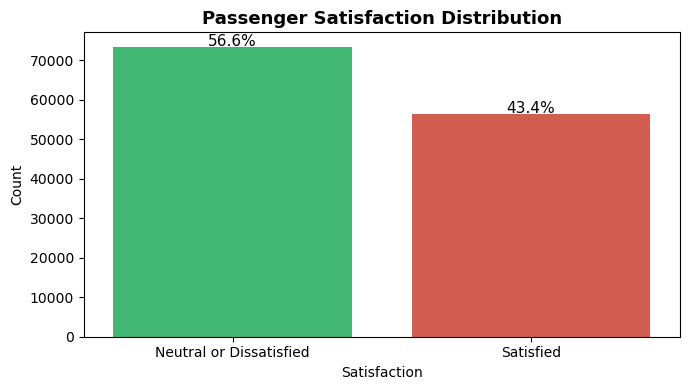

In [11]:
# Target variable distribution
target_counts = df['Satisfaction'].value_counts()
target_pct = df['Satisfaction'].value_counts(normalize=True) * 100

print("=== Target Variable Distribution ===")
print(target_counts)
print("\nPercentage:")
print(target_pct.round(2))

# Plot
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='Satisfaction', palette=['#2ecc71', '#e74c3c'])
plt.title('Passenger Satisfaction Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Satisfaction')
plt.ylabel('Count')

# Add percentage labels on bars
for p in ax.patches:
    pct = f"{100 * p.get_height() / len(df):.1f}%"
    ax.annotate(pct, (p.get_x() + p.get_width()/2, p.get_height() + 300), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

Numerical columns: ['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Departure and Arrival Time Convenience', 'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling']
Count: 18


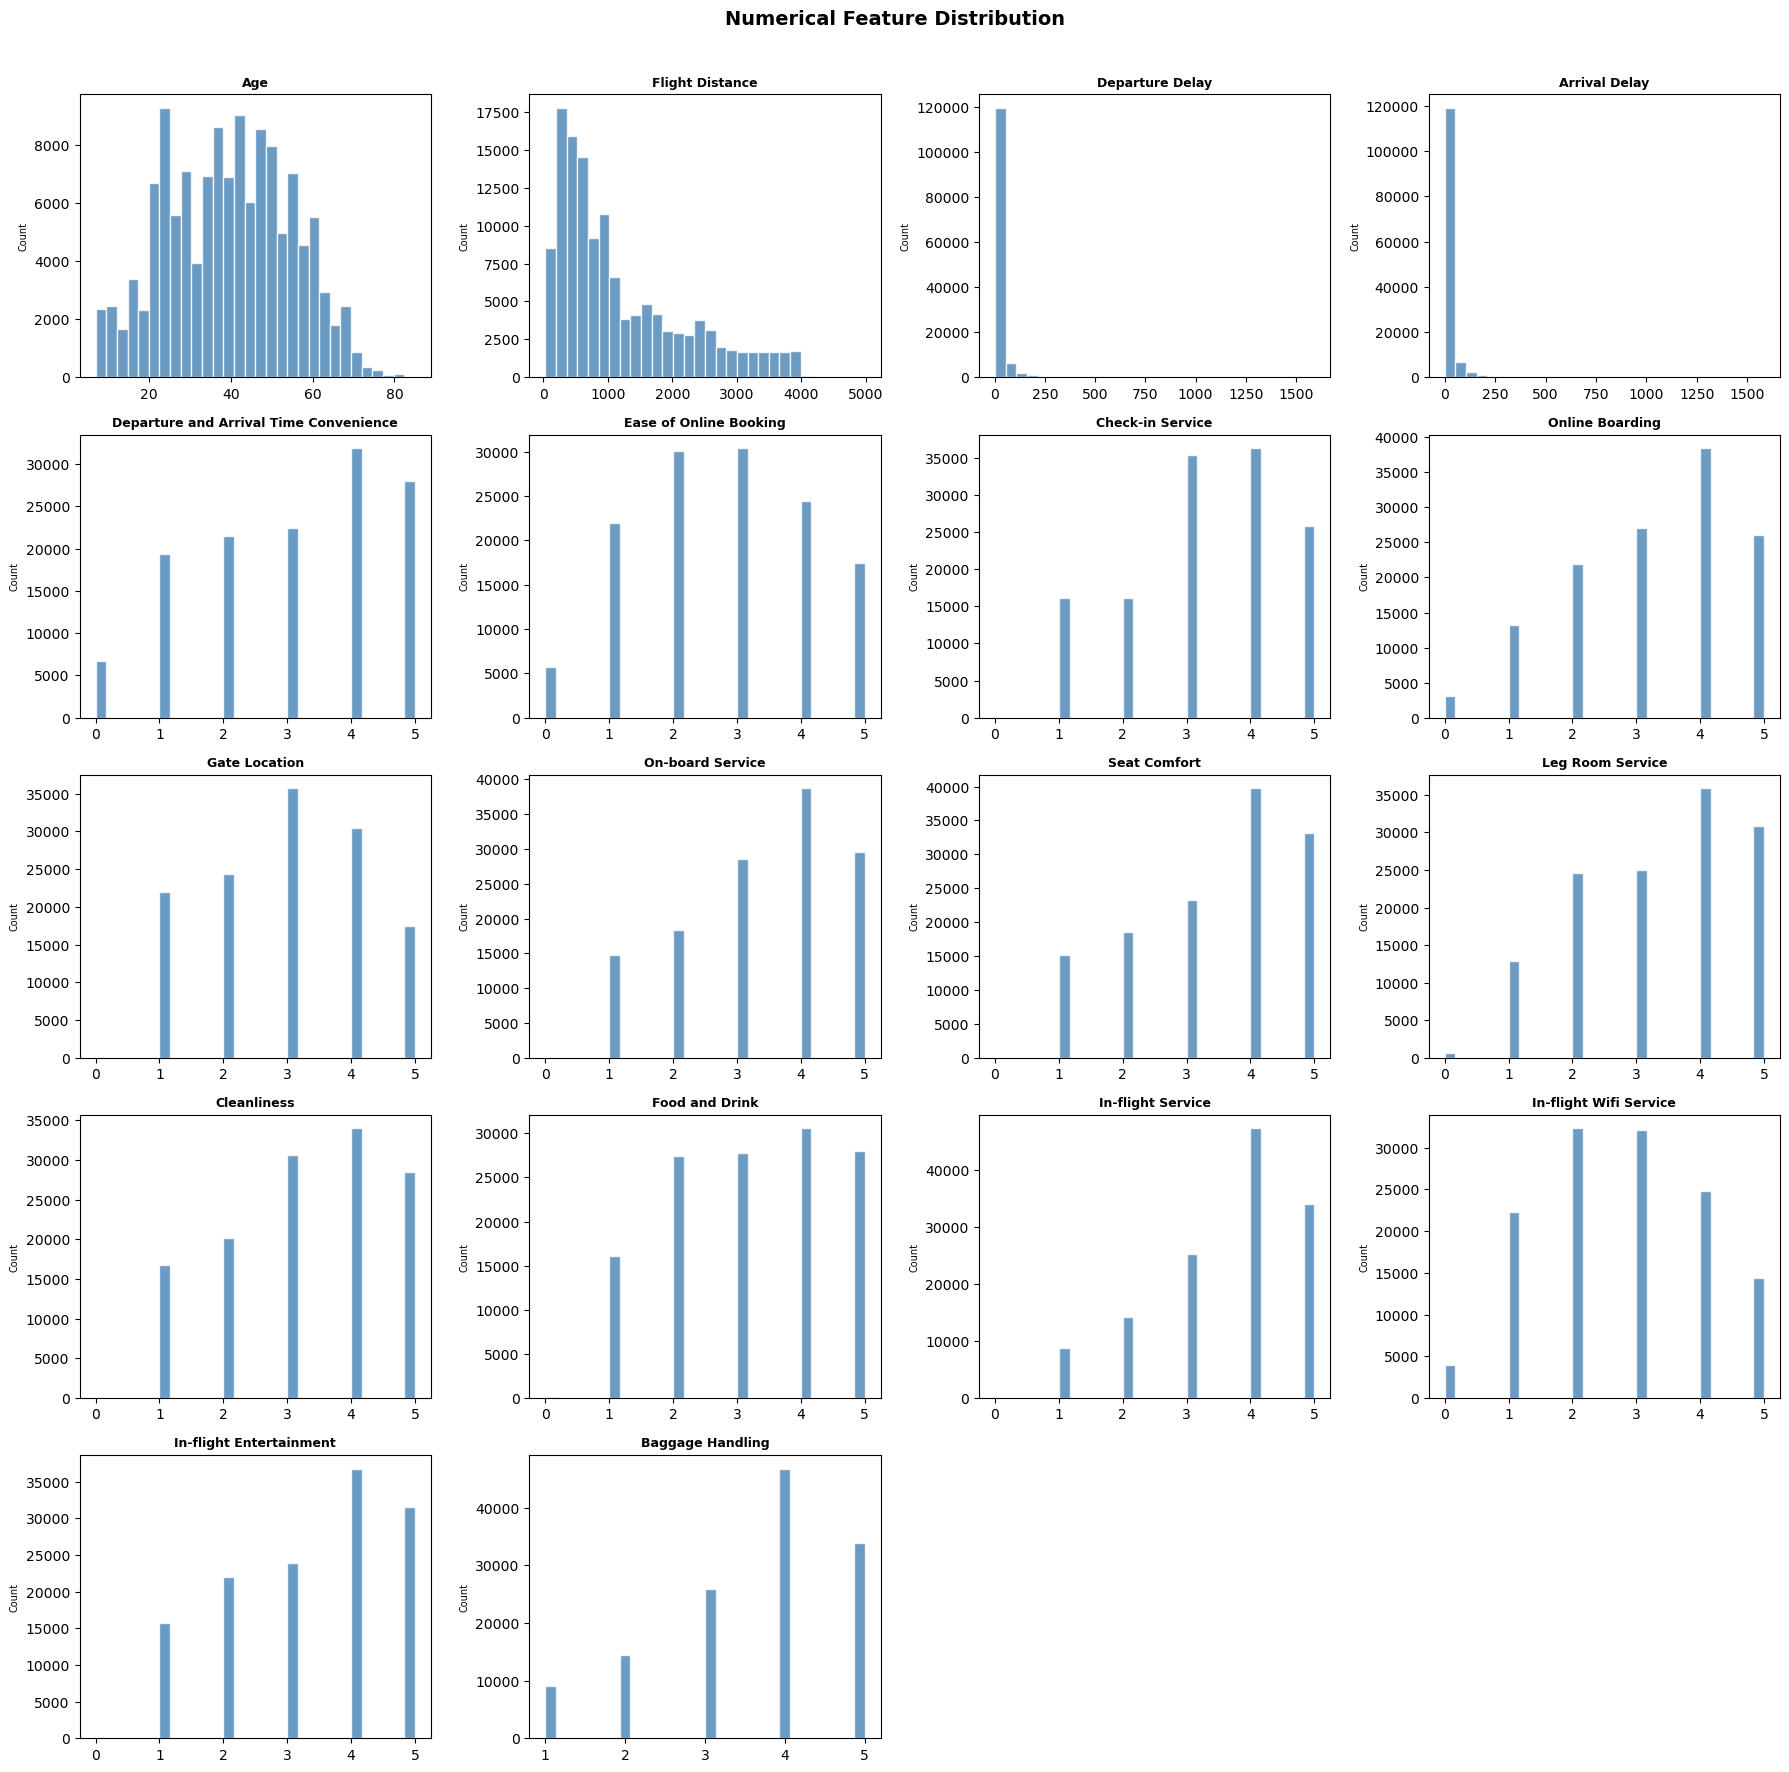

In [12]:
# Numerical feature distribution
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical columns:", num_cols)
print("Count:", len(num_cols))

# Calculate grid size dynamically
n_cols = 4
n_rows = -(-len(num_cols) // n_cols) # ceiling division

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, n_rows*3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Count', fontsize=7)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Categorical columns: ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'Satisfaction']


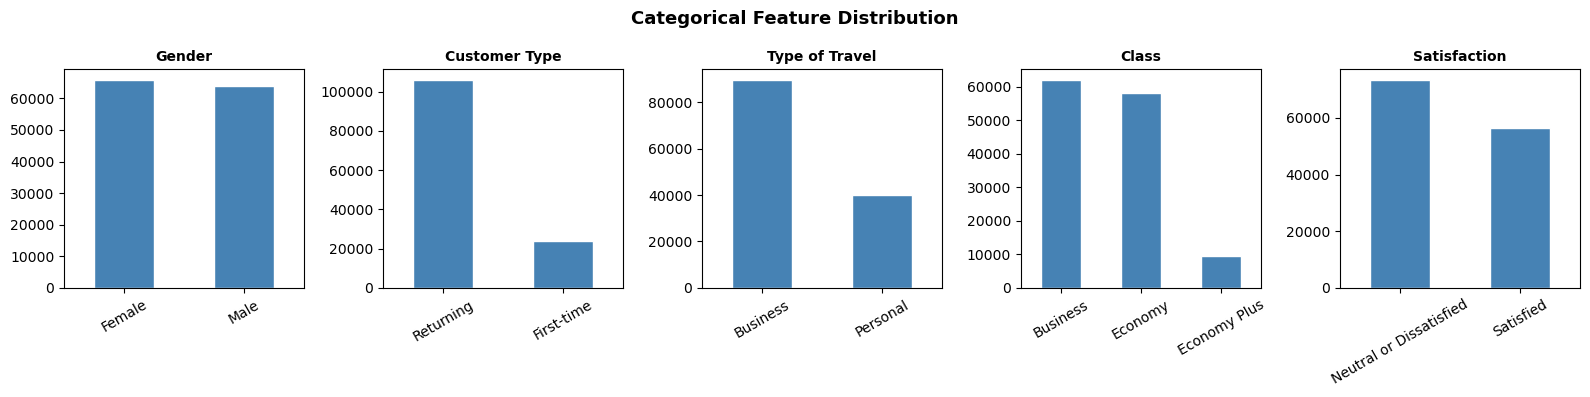

In [13]:
# Categorical feature distribution
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

fig, axes = plt.subplots(nrows=1, ncols=len(cat_cols), figsize=(16, 4))

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Categorical Feature Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

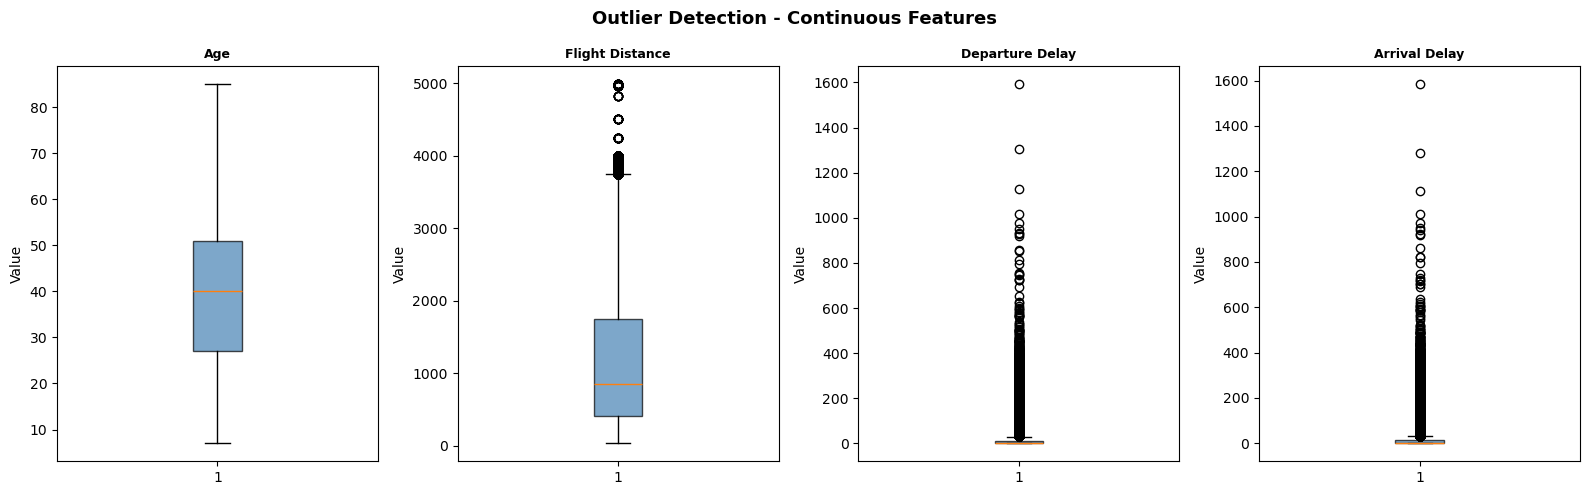

=== Outlier Summary===
Age: 0 outliers (0.00%)
Flight Distance: 2855 outliers (2.20%)
Departure Delay: 18098 outliers (13.93%)
Arrival Delay: 17492 outliers (13.47%)


In [14]:
# Boxplot for Outlier detection
# Focus on continuous columns only (not rating columns 0-5)

continuous_cols = [
    'Age',
    'Flight Distance',
    'Departure Delay',
    'Arrival Delay'
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(continuous_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Outlier Detection - Continuous Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print IQR stats
print("=== Outlier Summary===")
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)].shape[0]
    print(f"{col}: {outliers} outliers ({outliers/len(df)*100:.2f}%)")

In [15]:
# Outlier Treatment Decision
print("""
=== Outlier Treatment Decision ===

Age: 0 outliers — no action needed

Flight Distance: 2.20% outliers
→ These represent genuine long-haul flights
→ Removing them loses real passenger segments
→ Decision: KEEP — tree-based models are robust to outliers

Arrival Delay: 13.47% outliers  
→ These represent genuinely long delays (real events)
→ A 3-hour delay is meaningful for satisfaction prediction
→ Decision: KEEP — outliers carry predictive signal
→ Tree-based models (RF, GBM) are not sensitive to outlier values
      
Note: If using Linear/KNN models, we would cap these using
IQR winsorization. For tree-based models, no treatment needed.
""")


=== Outlier Treatment Decision ===

Age: 0 outliers — no action needed

Flight Distance: 2.20% outliers
→ These represent genuine long-haul flights
→ Removing them loses real passenger segments
→ Decision: KEEP — tree-based models are robust to outliers

Arrival Delay: 13.47% outliers  
→ These represent genuinely long delays (real events)
→ A 3-hour delay is meaningful for satisfaction prediction
→ Decision: KEEP — outliers carry predictive signal
→ Tree-based models (RF, GBM) are not sensitive to outlier values
      
Note: If using Linear/KNN models, we would cap these using
IQR winsorization. For tree-based models, no treatment needed.



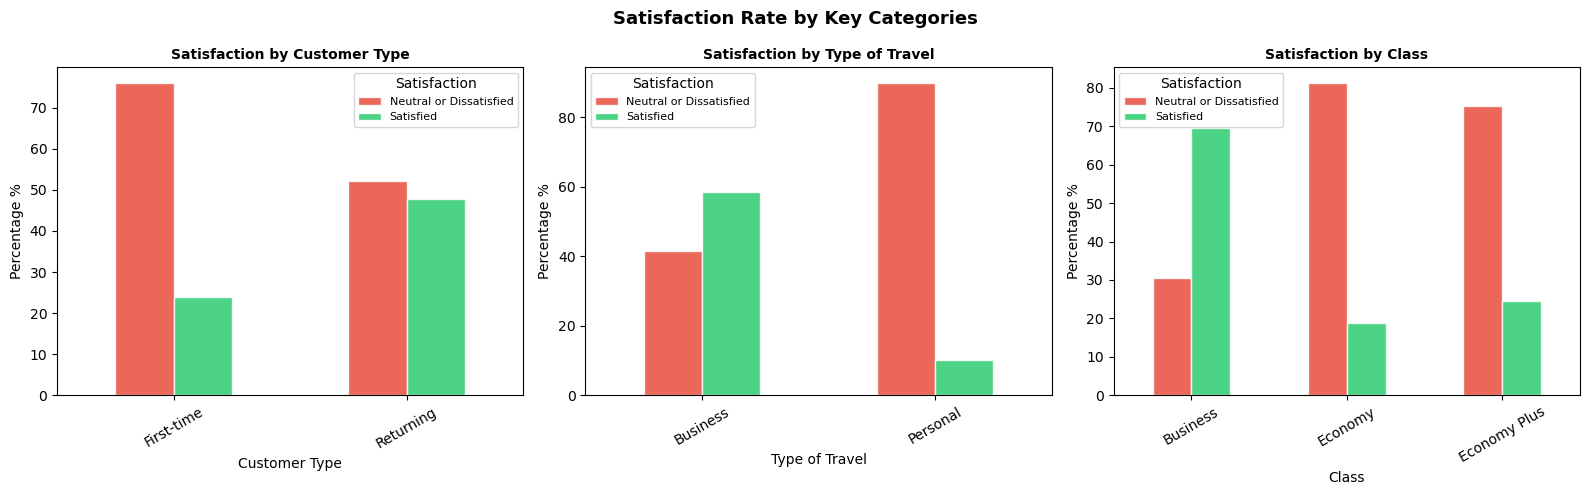

In [16]:
# How satisfaction relates to categorical features
# satisfaction vs categorical feature

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['Customer Type', 'Type of Travel', 'Class']):
    ct = pd.crosstab(df[col], df['Satisfaction'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i],
           color=['#e74c3c', '#2ecc71'],
           edgecolor='white', alpha=0.85)
    axes[i].set_title(f"Satisfaction by {col}", fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Percentage %')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Satisfaction', fontsize=8)

plt.suptitle('Satisfaction Rate by Key Categories', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

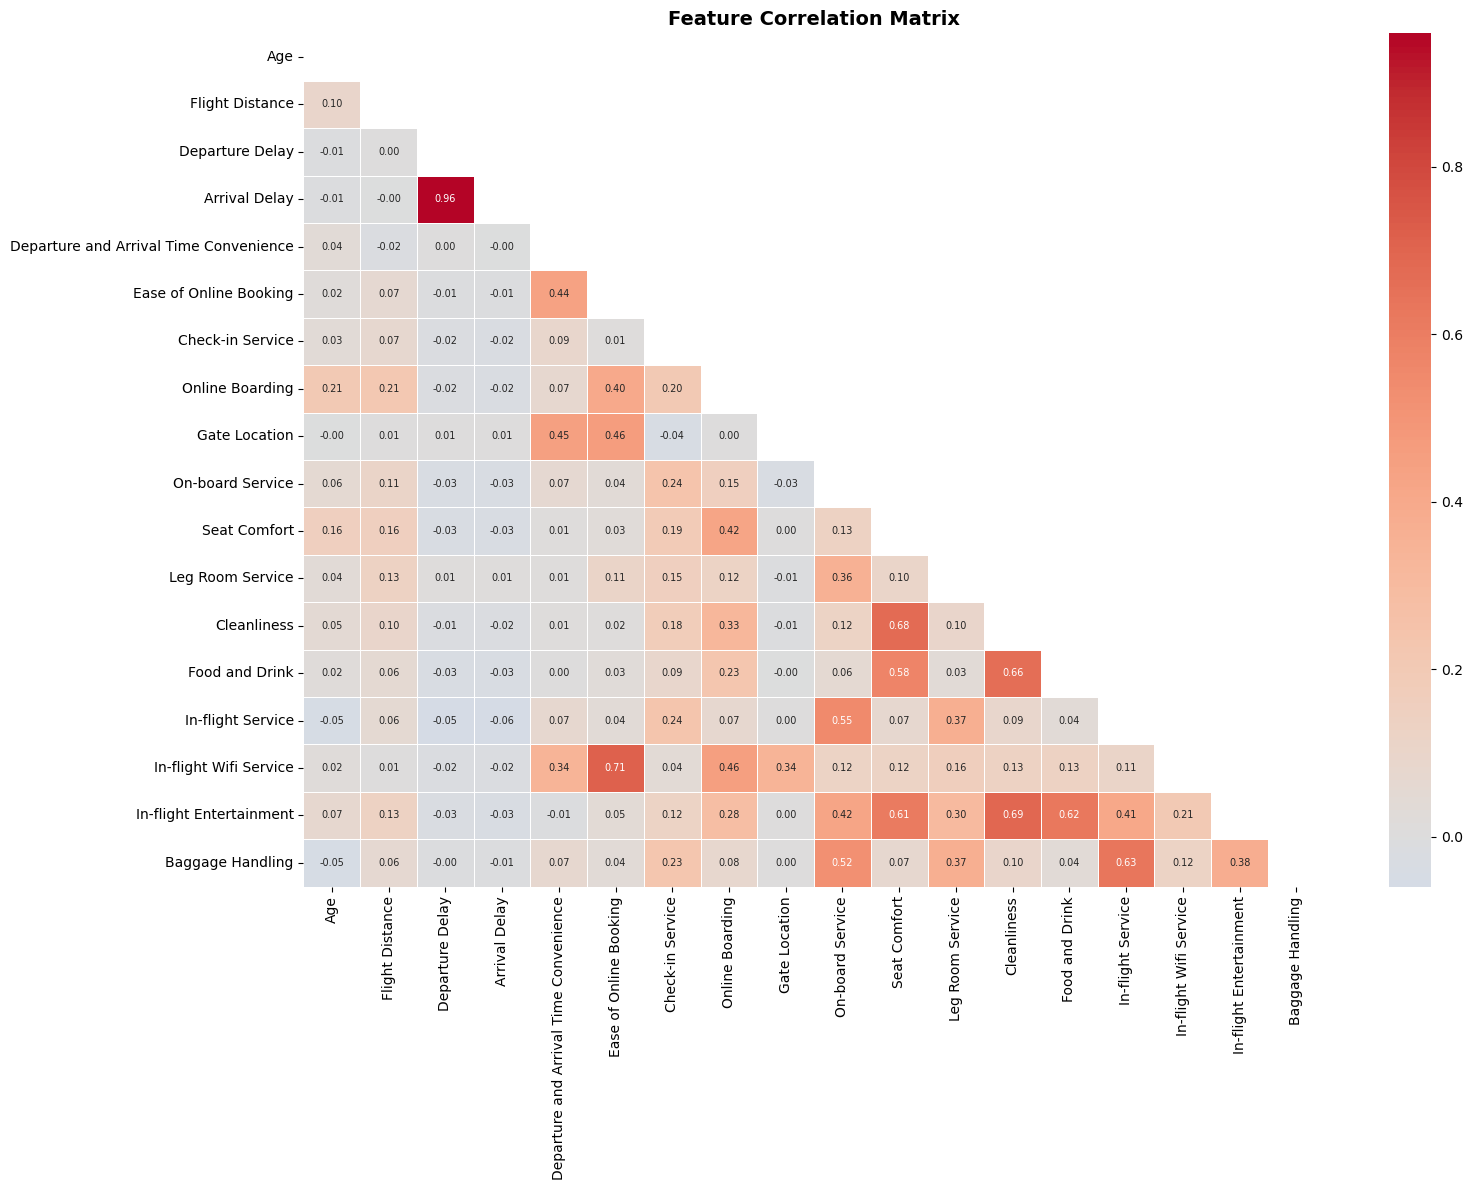

=== Top correlations with Satisfaction ===
Satisfaction               1.000000
Online Boarding            0.501749
In-flight Entertainment    0.398234
Seat Comfort               0.348829
On-board Service           0.322205
Leg Room Service           0.312424
Cleanliness                0.307035
Flight Distance            0.298104
In-flight Wifi Service     0.283460
Baggage Handling           0.248680
Name: Satisfaction, dtype: float64


In [17]:
# Correlation heatmap
plt.figure(figsize=(16, 12))

# select only numerical columns
num_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = num_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
           mask=mask,
           annot=True,
           fmt='.2f',
           cmap='coolwarm',
           center=0,
           linewidths=0.5,
           annot_kws={'size':7})

plt.title('Feature Correlation Matrix',
         fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlations with target (after encoding)
print("=== Top correlations with Satisfaction ===")
temp = df.copy()
temp['Satisfaction'] = (temp['Satisfaction'] == 'Satisfied').astype(int)
corrs = temp.select_dtypes(include=['int64','float64']).corr()['Satisfaction'].abs()
print(corrs.sort_values(ascending=False).head(10))

In [18]:
# Drop Departure Delay
# Handle multicollinearity
print("Correlation between Departure and Arrival Delay:")
print(df[['Departure Delay', 'Arrival Delay']].corr())

# Drop Departure Delay — highly correlated with Arrival Delay
# Arrival Delay is more directly tied to passenger experience
df = df.drop(columns=['Departure Delay'])
print("\nDropped Departure Delay")
print("New shape:", df.shape)

Correlation between Departure and Arrival Delay:
                 Departure Delay  Arrival Delay
Departure Delay         1.000000       0.959382
Arrival Delay           0.959382       1.000000

Dropped Departure Delay
New shape: (129880, 22)


In [19]:
# Encode categorical columns
le = LabelEncoder()

# Binary columns - Label Encoding is fine (Only 2 categories)
binary_cols = ['Gender', 'Customer Type', 'Type of Travel']

for col in binary_cols:
    print(f"{col}: {df[col].unique()}")
    df[col] = le.fit_transform(df[col])
    print(f" -> encoded as: {df[col].unique()}\n")

# Class - Ordinal encoding (Eco < Eco Plus < Business makes sense)
class_mapping = {'Eco': 0, 'Eco Plus': 1, 'Business': 2}
df['Class'] = df['Class'].map(class_mapping)
print("Class encoded as ordinal:", class_mapping)

# Target - Binary encoding
df['Satisfaction'] = (df['Satisfaction'] == 'Satisfied').astype(int)
print("\nSatisfaction: Satisfied=1, Neutral or Dissatisfied=0")

print("\nFinal dtype check:")
print(df.dtypes)

Gender: ['Male' 'Female']
 -> encoded as: [1 0]

Customer Type: ['First-time' 'Returning']
 -> encoded as: [0 1]

Type of Travel: ['Business' 'Personal']
 -> encoded as: [0 1]

Class encoded as ordinal: {'Eco': 0, 'Eco Plus': 1, 'Business': 2}

Satisfaction: Satisfied=1, Neutral or Dissatisfied=0

Final dtype check:
Gender                                      int64
Age                                         int64
Customer Type                               int64
Type of Travel                              int64
Class                                     float64
Flight Distance                           float64
Arrival Delay                             float64
Departure and Arrival Time Convenience      int64
Ease of Online Booking                      int64
Check-in Service                            int64
Online Boarding                             int64
Gate Location                               int64
On-board Service                            int64
Seat Comfort                    

In [20]:
# Fix Class mapping (correct column values)
df['Class'] = pd.read_csv('DS-DATA.csv')['Class']

class_mapping = {'Economy': 0, 'Economy Plus': 1, 'Business': 2}
df['Class'] = df['Class'].map(class_mapping)

print("Class value counts after mapping:")
print(df['Class'].value_counts())
print("\nAny nulls:", df['Class'].isnull().sum())

Class value counts after mapping:
Class
2    62160
0    58309
1     9411
Name: count, dtype: int64

Any nulls: 0


In [21]:
# train-test split
X = df.drop(columns=['Satisfaction'])
y = df['Satisfaction']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts(normalize=True).round(3) * 100)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain target distribution:")
print(y_train.value_counts(normalize=True).round(3) * 100)
print(f"\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3) * 100)

Features shape: (129880, 21)
Target shape: (129880,)

Target distribution:
Satisfaction
0    56.6
1    43.4
Name: proportion, dtype: float64
nTraining set: (103904, 21)
Test set: (25976, 21)

Train target distribution:
Satisfaction
0    56.6
1    43.4
Name: proportion, dtype: float64

Test target distribution:
Satisfaction
0    56.6
1    43.4
Name: proportion, dtype: float64


In [22]:
# Feature Scaling

scaler = StandardScaler()

# Fit ONLY on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")
print("Train mean (should be ~0):", X_train_scaled.mean().round(3))
print("Train std (should be ~1):", X_train_scaled.std().round(3))
print("Test mean (not forced to 0):", X_test_scaled.mean().round(3))

Scaling complete
Train mean (should be ~0): 0.0
Train std (should be ~1): 1.0
Test mean (not forced to 0): -0.001


In [23]:
# Model Training
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import time

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000,
                                             class_weight='balanced',
                                             random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced',
                                           random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100,
                                           class_weight='balanced',
                                           random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100,
                                                   random_state=42)
}

results = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = round(time.time() - start, 2)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]

    results[name] = {
        'Accuracy': round(accuracy_score(y_test, y_pred) * 100, 2),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4),
        'Train Time': train_time
    }
    print(f"{name} done ({train_time}s)")

# Display results
results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
print("\n=== Model Comparison ===")
print(results_df)

Logistic Regression done (0.45s)
Decision Tree done (1.18s)
Random Forest done (18.44s)
Gradient Boosting done (20.24s)

=== Model Comparison ===
                     Accuracy  ROC-AUC  F1 Score  Train Time
Random Forest           96.42   0.9946    0.9581       18.44
Gradient Boosting       94.30   0.9879    0.9335       20.24
Decision Tree           94.85   0.9479    0.9409        1.18
Logistic Regression     87.11   0.9292    0.8532        0.45


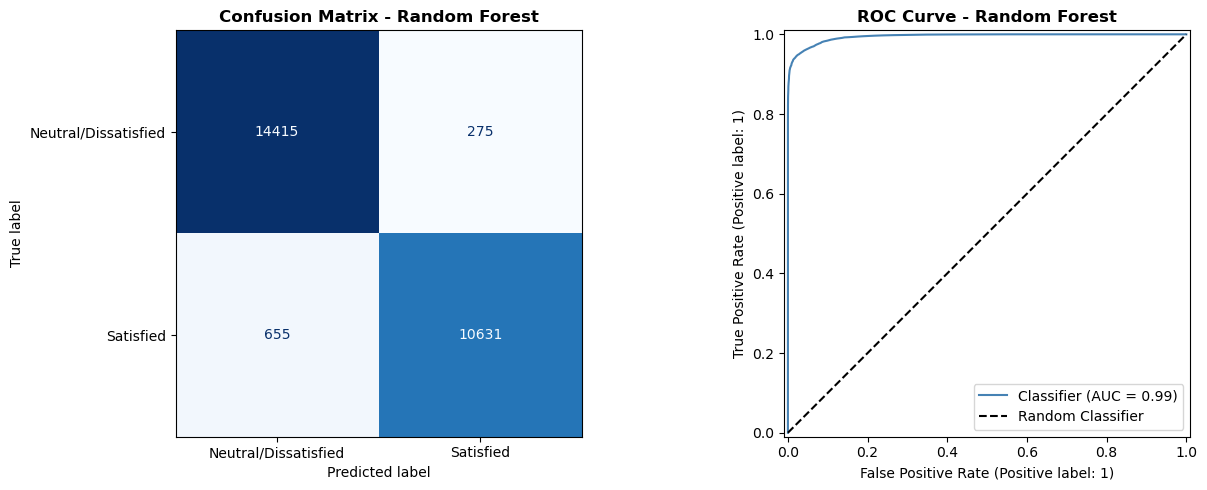

=== Classification Report ===
                      precision    recall  f1-score   support

Neutral/Dissatisfied       0.96      0.98      0.97     14690
           Satisfied       0.97      0.94      0.96     11286

            accuracy                           0.96     25976
           macro avg       0.97      0.96      0.96     25976
        weighted avg       0.96      0.96      0.96     25976



In [24]:
# Detailed evaluation of best model
from sklearn.metrics import (confusion_matrix, classification_report, RocCurveDisplay, ConfusionMatrixDisplay)

best_model = models['Random Forest']
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:,1]

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=['Neutral/Dissatisfied', 'Satisfied'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix - Random Forest', fontweight='bold')

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1],
                                color='steelblue')
axes[1].plot([0,1],[0,1], 'k--', label='Random Classifier')
axes[1].set_title('ROC Curve - Random Forest', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Classification Report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred,
                           target_names=['Neutral/Dissatisfied', 'Satisfied']))

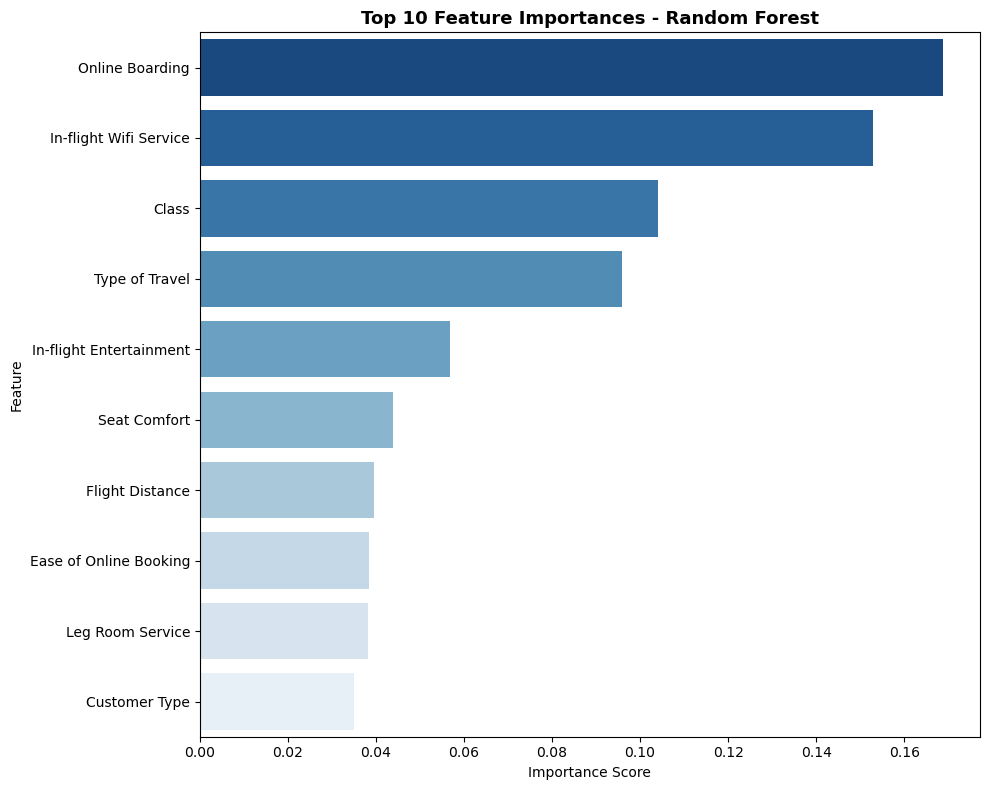

=== Top 10 Features ===
                    Feature  Importance
10          Online Boarding    0.168755
18   In-flight Wifi Service    0.152878
4                     Class    0.104051
3            Type of Travel    0.095811
19  In-flight Entertainment    0.056724
13             Seat Comfort    0.043801
5           Flight Distance    0.039645
8    Ease of Online Booking    0.038395
14         Leg Room Service    0.038316
2             Customer Type    0.035048


In [25]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(10),
           x='Importance', y='Feature',
           palette='Blues_r')
plt.title('Top 10 Feature Importances - Random Forest',
         fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("=== Top 10 Features ===")
print(feature_importance.head(10))

In [26]:
# Cross Validation on best model
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model,
                           X_train_scaled, y_train,
                           cv=cv,
                           scoring='roc_auc')

print("=== 5-Fold Stratified Cross Validation ===")
print(f"Individual fold scores: {cv_scores.round(4)}")
print(f"Mean ROC-AUC: {cv_scores.mean().round(4)}")
print(f"Std deviation: {cv_scores.std().round(4)}")
print(f"Test ROC-AUC: 0.9946")
print(f"\nGap (CV mean vs Test): {abs(cv_scores.mean() - 0.9946).round(4)}")

=== 5-Fold Stratified Cross Validation ===
Individual fold scores: [0.9939 0.9939 0.9937 0.9941 0.9937]
Mean ROC-AUC: 0.9939
Std deviation: 0.0002
Test ROC-AUC: 0.9946

Gap (CV mean vs Test): 0.0007


In [27]:
# Hyperparameter Tuning (RandomizedSearchCV)
from sklearn.model_selection import RandomizedSearchCV

# Use 20% sample for tuning speed - explain this decision
X_tune, _, y_tune, _ = train_test_split(
    X_train_scaled, y_train,
    test_size=0.8,
    random_state=42,
    stratify=y_train
)

print(f"Tuning on {X_tune.shape[0]} samples for speed")

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_tuned = RandomForestClassifier(class_weight='balanced', random_state=42)

random_search = RandomizedSearchCV(
    rf_tuned,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_tune, y_tune)

print("\n=== Best Parameters ===")
print(random_search.best_params_)
print(f"\nBest CV ROC-AUC during tuning: {random_search.best_score_:.4f}")

Tuning on 20780 samples for speed
Fitting 3 folds for each of 20 candidates, totalling 60 fits

=== Best Parameters ===
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

Best CV ROC-AUC during tuning: 0.9908


In [28]:
# Evaluate tuned model on full test set
best_tuned_model = random_search.best_estimator_

# Retrain best params on full training data
best_tuned_model.fit(X_train_scaled, y_train)

y_pred_tuned = best_tuned_model.predict(X_test_scaled)
y_prob_tuned = best_tuned_model.predict_proba(X_test_scaled)[:,1]

print("=== Tuned Model Performance ===")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned)*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_tuned):.4f}")

print("\n=== Comparison: Base vs Tuned ===")
print(f"Base Random Forest ROC-AUC:  0.9946")
print(f"Tuned Random Forest ROC-AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}")

=== Tuned Model Performance ===
ROC-AUC:  0.9946
Accuracy: 96.47%
F1 Score: 0.9586

=== Comparison: Base vs Tuned ===
Base Random Forest ROC-AUC:  0.9946
Tuned Random Forest ROC-AUC: 0.9946


In [29]:
# Business Conclusions
print("""
=== AIRLINE PASSENGER SATISFACTION — KEY FINDINGS ===

DATASET: 129,880 passengers | 21 features | Binary classification

BEST MODEL: Random Forest (with Hyperparameter Tuning)
- ROC-AUC:  0.9946 — model separates satisfied vs 
                      dissatisfied passengers excellently
- Accuracy: 96.47%
- F1 Score: 0.9586
- Recall (Dissatisfied): 0.98 — catches 98% of unhappy passengers
- Overfitting check: CV mean 0.9939 vs Test 0.9946 — gap of 0.0007

TOP SATISFACTION DRIVERS:
1. Online Boarding (0.17)     — biggest lever for improvement
2. In-flight Wifi (0.15)      — second highest impact
3. Class (0.10)               — Business >> Economy satisfaction
4. Type of Travel (0.09)      — Business travel >> Personal travel
5. In-flight Entertainment    — consistent top 5 predictor

KEY PASSENGER SEGMENTS NEEDING ATTENTION:
- Economy & Economy Plus passengers — largely dissatisfied
- First-time passengers — high dissatisfaction, high churn risk  
- Personal travel passengers — significantly less satisfied

BUSINESS RECOMMENDATIONS:
1. Invest in digital boarding experience — highest ROI action
2. Improve inflight Wifi reliability — second highest impact
3. Design re-engagement program for first-time Economy passengers
4. Personalise services for personal travel segment
5. Deploy model to flag high-risk dissatisfied passengers 
   before they churn — enable proactive intervention

MODEL CONSISTENCY CHECK:
- EDA correlation top feature: Online Boarding (0.50)
- Model feature importance top feature: Online Boarding (0.17)
- Both analyses agree — results are reliable and consistent
""")


=== AIRLINE PASSENGER SATISFACTION — KEY FINDINGS ===

DATASET: 129,880 passengers | 21 features | Binary classification

BEST MODEL: Random Forest (with Hyperparameter Tuning)
- ROC-AUC:  0.9946 — model separates satisfied vs 
                      dissatisfied passengers excellently
- Accuracy: 96.47%
- F1 Score: 0.9586
- Recall (Dissatisfied): 0.98 — catches 98% of unhappy passengers
- Overfitting check: CV mean 0.9939 vs Test 0.9946 — gap of 0.0007

TOP SATISFACTION DRIVERS:
1. Online Boarding (0.17)     — biggest lever for improvement
2. In-flight Wifi (0.15)      — second highest impact
3. Class (0.10)               — Business >> Economy satisfaction
4. Type of Travel (0.09)      — Business travel >> Personal travel
5. In-flight Entertainment    — consistent top 5 predictor

KEY PASSENGER SEGMENTS NEEDING ATTENTION:
- Economy & Economy Plus passengers — largely dissatisfied
- First-time passengers — high dissatisfaction, high churn risk  
- Personal travel passengers — significa